# Notebook 11 · Crypto Real Data Pipeline
### Download · Clean · Calibrate · Export (BTC, ETH)


**Goal :** Download real Binance aggTrades for BTCUSDT and ETHUSDT, build 1-second VWAP
mid-prices, calibrate Guéant model parameters (sigma, A, k), estimate BTC/ETH
correlation, and export files ready for Notebook 08 and the Streamlit dashboard.


**Design principles :**
- Crypto only: BTCUSDT and ETHUSDT
- Process day by day to keep memory bounded
- Smart skip if final outputs already exist
- Reuse calibrate.py logic instead of duplicating calibration code


# 0. imports and configuration 

In [36]:
import io
import json
import pickle
import zipfile
import warnings
from pathlib import Path
from datetime import datetime, timedelta
from scipy.optimize import curve_fit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8")
%matplotlib inline

import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.data.calibrate import compute_mid_price, compute_mid_price_tick, estimate_sigma, estimate_intensity, calibrate, calibrate_pair
from market_making.core.intensity import C_coeff

In [37]:
SYMBOLS = ["BTCUSDT", "ETHUSDT"]
N_DAYS = 30
END_DATE = "2025-06-03"
FREQ = "1s"
FORCE_RERUN = True

RAW_DIR = Path("data/raw")
OUT_DIR = Path("data/calibrated")
CKPT_DIR = OUT_DIR / "checkpoints"

RAW_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

_end = datetime.strptime(END_DATE, "%Y-%m-%d")
START_DATE = (_end - timedelta(days=N_DAYS - 1)).strftime("%Y-%m-%d")

LOT_SIZES = {
    "BTCUSDT": 0.001,
    "ETHUSDT": 0.01,
}
Q_MAX = 4

print(f"Symbols:   {', '.join(SYMBOLS)}")
print(f"Period:    {START_DATE} -> {END_DATE} ({N_DAYS} days)")
print(f"Frequency: {FREQ}")
print(f"Raw dir:   {RAW_DIR.resolve()}")
print(f"Out dir:   {OUT_DIR.resolve()}")

Symbols:   BTCUSDT, ETHUSDT
Period:    2025-05-05 -> 2025-06-03 (30 days)
Frequency: 1s
Raw dir:   /Users/hamzaelarji/Desktop/All/Bureau/cours/Imperial College/Term 2/Elective modules/Chosen Elective Modules /Market Microstructure/Coursework/Market-Microstructure-/project/data/data/raw
Out dir:   /Users/hamzaelarji/Desktop/All/Bureau/cours/Imperial College/Term 2/Elective modules/Chosen Elective Modules /Market Microstructure/Coursework/Market-Microstructure-/project/data/data/calibrated


# 1. Load existing data if any

In [38]:
def outputs_complete(symbols, out_dir: Path) -> bool:
    json_ok = (out_dir / "calibrated_params.json").exists()
    mids_ok = all((out_dir / f"mid_prices_{s}.parquet").exists() for s in symbols)
    stats_ok = all((out_dir / f"daily_stats_{s}.csv").exists() for s in symbols)
    return json_ok and mids_ok and stats_ok

PIPELINE_DONE = outputs_complete(SYMBOLS, OUT_DIR) and not FORCE_RERUN

if PIPELINE_DONE:
    print("All final outputs already exist. Download and processing will be skipped.")
else:
    print("Missing outputs or FORCE_RERUN=True. Full pipeline will run.")

Missing outputs or FORCE_RERUN=True. Full pipeline will run.


In [39]:
calibrated = {}
mid_series = {}
daily_stats_loaded = {}

if PIPELINE_DONE:
    with open(OUT_DIR / "calibrated_params.json", "r") as f:
        raw_params = json.load(f)

    for sym in SYMBOLS:
        if sym in raw_params:
            calibrated[sym] = dict(raw_params[sym])

        pq = OUT_DIR / f"mid_prices_{sym}.parquet"
        if pq.exists():
            mid_series[sym] = pd.read_parquet(pq)["mid_price"]

        stats_csv = OUT_DIR / f"daily_stats_{sym}.csv"
        if stats_csv.exists():
            daily_stats_loaded[sym] = pd.read_csv(stats_csv)

    if "cross_correlation" in raw_params:
        calibrated["rho"] = raw_params["cross_correlation"].get("rho")

    print("Loaded existing calibrated outputs:")
    for sym in SYMBOLS:
        if sym in calibrated:
            print(f"  {sym}: sigma={calibrated[sym]['sigma']:.6f}, "
                  f"A={calibrated[sym]['A']:.6f}, k={calibrated[sym]['k']:.6f}, "
                  f"rows={len(mid_series.get(sym, [])):,}")

# 2. Downoald data

In [40]:
BASE_URL = "https://data.binance.vision/data/spot/daily/aggTrades"
AGGTRADE_COLS = [
    "agg_trade_id",
    "price",
    "quantity",
    "first_trade_id",
    "last_trade_id",
    "transact_time",
    "is_buyer_maker",
    "ignore",
]

def download_day(symbol: str, date_str: str, out_dir: Path) -> Path | None:
    fname = f"{symbol}-aggTrades-{date_str}"
    csv_path = out_dir / f"{fname}.csv"

    if csv_path.exists():
        return csv_path

    url = f"{BASE_URL}/{symbol}/{fname}.zip"
    try:
        resp = requests.get(url, timeout=60)
        if resp.status_code != 200:
            return None
    except requests.RequestException:
        return None

    try:
        with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
            csv_name = [n for n in zf.namelist() if n.endswith(".csv")][0]
            zf.extract(csv_name, out_dir)
            extracted = out_dir / csv_name
            if extracted != csv_path:
                extracted.rename(csv_path)
    except Exception:
        return None

    return csv_path


def load_day(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, header=None, names=AGGTRADE_COLS)

    df["transact_time"] = pd.to_numeric(df["transact_time"], errors="coerce")
    df["timestamp"] = pd.to_datetime(df["transact_time"], unit="us", errors="coerce")  # ← back to us
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
    df["is_buyer_maker"] = (
        df["is_buyer_maker"].astype(str).str.lower()
        .map({"true": True, "false": False})
    )

    df = df.dropna(subset=["timestamp", "price", "quantity", "is_buyer_maker"])
    return df[["timestamp", "price", "quantity", "is_buyer_maker"]]

# 3. Downoald daily files

In [41]:
if PIPELINE_DONE:
    print("Download skipped.")
else:
    for symbol in SYMBOLS:
        sym_dir = RAW_DIR / symbol
        sym_dir.mkdir(parents=True, exist_ok=True)

        d = datetime.strptime(START_DATE, "%Y-%m-%d")
        d_end = datetime.strptime(END_DATE, "%Y-%m-%d")
        total = (d_end - d).days + 1
        ok, fail = 0, 0

        print(f"\nDownloading {symbol} ({total} days)")
        while d <= d_end:
            date_str = d.strftime("%Y-%m-%d")
            day_num = (d - datetime.strptime(START_DATE, "%Y-%m-%d")).days + 1

            print(f"  [{day_num:3d}/{total}] {date_str} ... ", end="", flush=True)
            p = download_day(symbol, date_str, sym_dir)

            if p is not None:
                print("OK")
                ok += 1
            else:
                print("SKIP")
                fail += 1

            d += timedelta(days=1)

        print(f"  Result: {ok}/{total} downloaded, {fail} missing")


  [  1/30] 2025-05-05 ... OK
  [  2/30] 2025-05-06 ... OK
  [  3/30] 2025-05-07 ... OK
  [  4/30] 2025-05-08 ... OK
  [  5/30] 2025-05-09 ... OK
  [  6/30] 2025-05-10 ... OK
  [  7/30] 2025-05-11 ... OK
  [  8/30] 2025-05-12 ... OK
  [  9/30] 2025-05-13 ... OK
  [ 10/30] 2025-05-14 ... OK
  [ 11/30] 2025-05-15 ... OK
  [ 12/30] 2025-05-16 ... OK
  [ 13/30] 2025-05-17 ... OK
  [ 14/30] 2025-05-18 ... OK
  [ 15/30] 2025-05-19 ... OK
  [ 16/30] 2025-05-20 ... OK
  [ 17/30] 2025-05-21 ... OK
  [ 18/30] 2025-05-22 ... OK
  [ 19/30] 2025-05-23 ... OK
  [ 20/30] 2025-05-24 ... OK
  [ 21/30] 2025-05-25 ... OK
  [ 22/30] 2025-05-26 ... OK
  [ 23/30] 2025-05-27 ... OK
  [ 24/30] 2025-05-28 ... OK
  [ 25/30] 2025-05-29 ... OK
  [ 26/30] 2025-05-30 ... OK
  [ 27/30] 2025-05-31 ... OK
  [ 28/30] 2025-06-01 ... OK
  [ 29/30] 2025-06-02 ... OK
  [ 30/30] 2025-06-03 ... OK
  Result: 30/30 downloaded, 0 missing

  [  1/30] 2025-05-05 ... OK
  [  2/30] 2025-05-06 ... OK
  [  3/30] 2025-05-07 ... OK
  [

# 4. Quick Look on one sample day


BTCUSDT sample day
  Trades:    1,142,608
  Time span: 2025-05-20 00:00:00.007472 -> 2025-05-20 23:59:59.931912
  Price:     104,184.72 -> 107,320.00
  Mean qty:  0.020747
  Buyer ratio: 48.4%

ETHUSDT sample day
  Trades:    1,379,957
  Time span: 2025-05-20 00:00:00.031476 -> 2025-05-20 23:59:58.389827
  Price:     2,442.40 -> 2,588.63
  Mean qty:  0.490587
  Buyer ratio: 49.3%


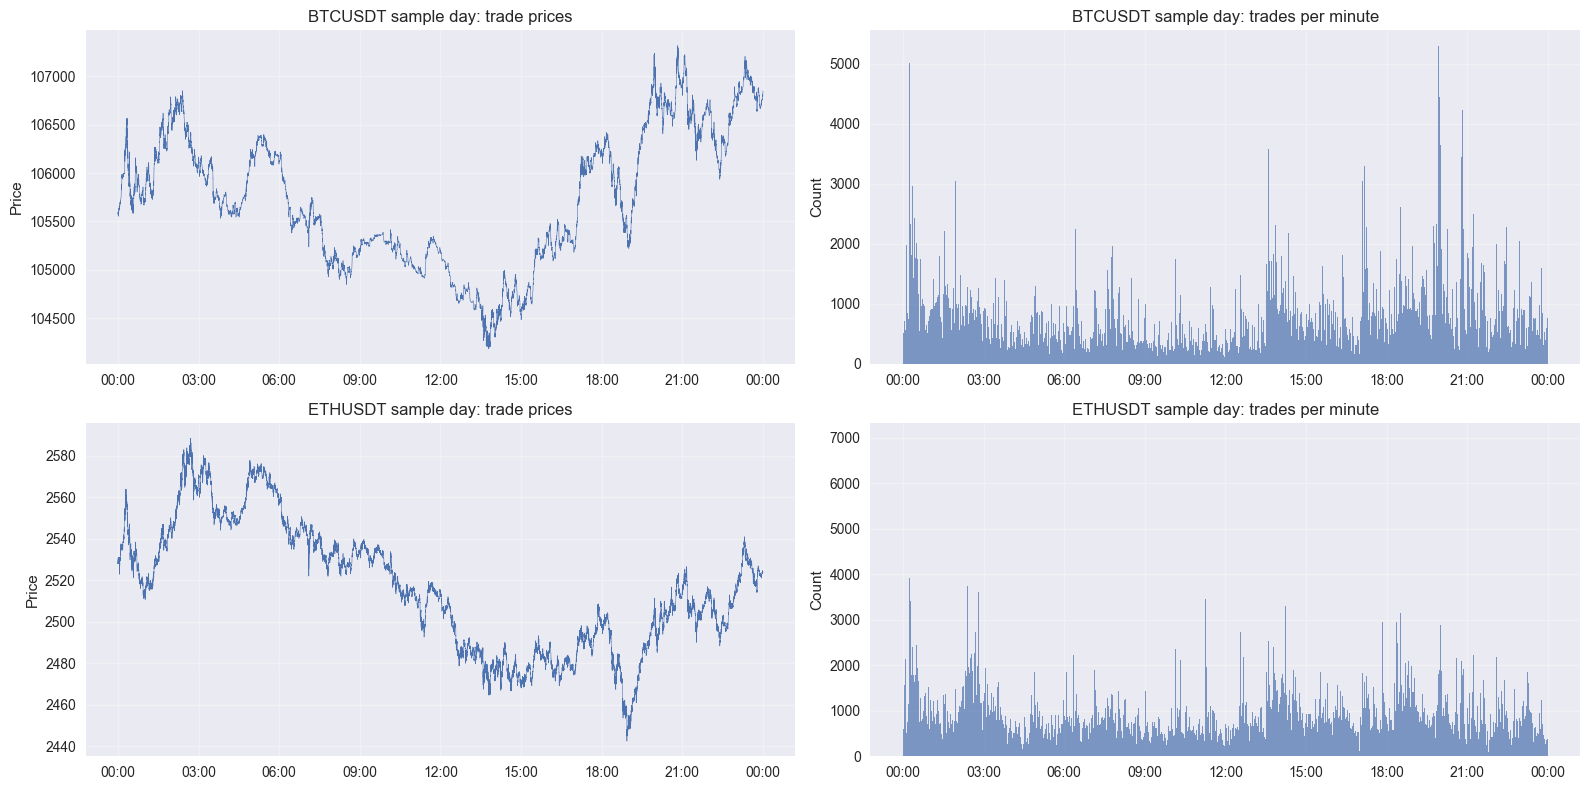

In [42]:
if PIPELINE_DONE:
    print("Quick look skipped.")
else:
    sample_data = {}

    for symbol in SYMBOLS:
        sym_dir = RAW_DIR / symbol
        csvs = sorted(sym_dir.glob("*.csv"))
        if not csvs:
            continue

        sample_path = csvs[len(csvs) // 2]
        df = load_day(sample_path)
        sample_data[symbol] = df

        print(f"\n{symbol} sample day")
        print(f"  Trades:    {len(df):,}")
        print(f"  Time span: {df['timestamp'].min()} -> {df['timestamp'].max()}")
        print(f"  Price:     {df['price'].min():,.2f} -> {df['price'].max():,.2f}")
        print(f"  Mean qty:  {df['quantity'].mean():.6f}")
        print(f"  Buyer ratio: {(~df['is_buyer_maker']).mean():.1%}")

    fig, axes = plt.subplots(len(sample_data), 2, figsize=(16, 4 * len(sample_data)))
    if len(sample_data) == 1:
        axes = np.array([axes])

    for row, (symbol, df) in enumerate(sample_data.items()):
        ax = axes[row, 0]
        ax.plot(df["timestamp"], df["price"], lw=0.4)
        ax.set_title(f"{symbol} sample day: trade prices")
        ax.set_ylabel("Price")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.grid(True, alpha=0.3)

        ax = axes[row, 1]
        freq_min = df.set_index("timestamp").resample("1min").size()
        ax.bar(freq_min.index, freq_min.values, width=1/1440, alpha=0.7)
        ax.set_title(f"{symbol} sample day: trades per minute")
        ax.set_ylabel("Count")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 5. Day by day processing

In [43]:
def save_checkpoint(symbol: str, state: dict) -> Path:
    ckpt_path = CKPT_DIR / f"{symbol}_checkpoint.pkl"
    tmp_path = CKPT_DIR / f"{symbol}_checkpoint.tmp"
    with open(tmp_path, "wb") as f:
        pickle.dump(state, f)
    tmp_path.replace(ckpt_path)
    return ckpt_path


def load_checkpoint(symbol: str) -> dict | None:
    ckpt_path = CKPT_DIR / f"{symbol}_checkpoint.pkl"
    if not ckpt_path.exists():
        return None
    try:
        with open(ckpt_path, "rb") as f:
            return pickle.load(f)
    except Exception:
        ckpt_path.unlink(missing_ok=True)
        return None


def compute_deltas(trades: pd.DataFrame, mid: pd.Series) -> np.ndarray:
    """
    Compute delta = |trade_price - mid| where mid is the 1s VWAP.
    To avoid intra-second BTC drift inflating deltas, use the mid
    from the PREVIOUS second as reference (forward-looking bias removed).
    """
    t = trades.copy()
    t["second"] = t["timestamp"].dt.floor("1s")
    
    # shift mid by 1 period to use previous-second mid as reference
    mid_shifted = mid.shift(1).dropna()
    
    t = t.set_index("second")
    t["mid"] = mid_shifted.reindex(t.index, method="ffill")
    t = t.dropna(subset=["mid"])
    return np.abs(t["price"].values - t["mid"].values)

In [44]:
pipeline_results = {}
SAVE_EVERY = 5

if PIPELINE_DONE:
    print("Processing skipped.")
else:
    for symbol in SYMBOLS:
        sym_dir = RAW_DIR / symbol
        csvs = sorted(sym_dir.glob(f"{symbol}-aggTrades-*.csv"))

        if not csvs:
            print(f"{symbol}: no CSV files found.")
            continue

        ckpt = load_checkpoint(symbol)
        if ckpt is not None:
            print(f"\nResuming {symbol} from checkpoint "
                  f"({len(ckpt['processed_files'])} processed days)")
            all_mid = ckpt["all_mid"]
            all_returns = ckpt["all_returns"]
            all_deltas = ckpt["all_deltas"]
            daily_sigma = ckpt["daily_sigma"]
            daily_stats = ckpt["daily_stats"]
            total_seconds = ckpt["total_seconds"]
            total_trades = ckpt["total_trades"]
            processed_files = set(ckpt["processed_files"])
        else:
            all_mid, all_returns, all_deltas = [], [], []
            daily_sigma, daily_stats = [], []
            total_seconds, total_trades = 0.0, 0
            processed_files = set()

        print(f"\nProcessing {symbol} ({len(csvs)} files)")

        for i, csv_path in enumerate(csvs):
            day_label = csv_path.stem.split("aggTrades-")[-1]

            if csv_path.name in processed_files:
                print(f"  [{i+1:3d}/{len(csvs)}] {day_label} ... SKIP")
                continue

            print(f"  [{i+1:3d}/{len(csvs)}] {day_label} ... ", end="", flush=True)

            try:
                df = load_day(csv_path)
                if len(df) < 100:
                    print("TOO SMALL")
                    continue

                mid = compute_mid_price(df, freq = FREQ)
                if len(mid) < 100:
                    print("NO MID")
                    continue

                returns = mid.diff().dropna().values
                deltas = compute_deltas(df, mid)

                span = (df["timestamp"].max() - df["timestamp"].min()).total_seconds()

                all_mid.append(mid)
                all_returns.append(returns)
                all_deltas.append(deltas)
                daily_sigma.append(float(np.std(returns)))
                daily_stats.append({
                    "date": day_label,
                    "n_trades": len(df),
                    "mean_price": float(df["price"].mean()),
                    "sigma": float(np.std(returns)),
                    "span_hours": span / 3600.0,
                })

                total_seconds += span
                total_trades += len(df)
                processed_files.add(csv_path.name)

                print(f"OK ({len(df):,} trades)")

                if len(processed_files) % SAVE_EVERY == 0:
                    save_checkpoint(symbol, {
                        "all_mid": all_mid,
                        "all_returns": all_returns,
                        "all_deltas": all_deltas,
                        "daily_sigma": daily_sigma,
                        "daily_stats": daily_stats,
                        "total_seconds": total_seconds,
                        "total_trades": total_trades,
                        "processed_files": sorted(processed_files),
                    })

            except Exception as e:
                print(f"ERROR: {e}")

        final_state = {
            "all_mid": all_mid,
            "all_returns": all_returns,
            "all_deltas": all_deltas,
            "daily_sigma": daily_sigma,
            "daily_stats": daily_stats,
            "total_seconds": total_seconds,
            "total_trades": total_trades,
            "processed_files": sorted(processed_files),
        }
        save_checkpoint(symbol, final_state)

        pipeline_results[symbol] = final_state
        print(f"  Total trades: {total_trades:,}")
        print(f"  Total hours:  {total_seconds/3600:.1f}")


Processing BTCUSDT (30 files)
  [  1/30] 2025-05-05 ... OK (817,730 trades)
  [  2/30] 2025-05-06 ... OK (793,323 trades)
  [  3/30] 2025-05-07 ... OK (872,211 trades)
  [  4/30] 2025-05-08 ... OK (1,551,619 trades)
  [  5/30] 2025-05-09 ... OK (1,369,756 trades)
  [  6/30] 2025-05-10 ... OK (750,987 trades)
  [  7/30] 2025-05-11 ... OK (972,289 trades)
  [  8/30] 2025-05-12 ... OK (1,583,664 trades)
  [  9/30] 2025-05-13 ... OK (1,096,642 trades)
  [ 10/30] 2025-05-14 ... OK (895,663 trades)
  [ 11/30] 2025-05-15 ... OK (1,221,599 trades)
  [ 12/30] 2025-05-16 ... OK (985,097 trades)
  [ 13/30] 2025-05-17 ... OK (853,175 trades)
  [ 14/30] 2025-05-18 ... OK (1,155,135 trades)
  [ 15/30] 2025-05-19 ... OK (1,423,199 trades)
  [ 16/30] 2025-05-20 ... OK (1,142,608 trades)
  [ 17/30] 2025-05-21 ... OK (1,983,557 trades)
  [ 18/30] 2025-05-22 ... OK (1,631,145 trades)
  [ 19/30] 2025-05-23 ... OK (1,545,530 trades)
  [ 20/30] 2025-05-24 ... OK (887,342 trades)
  [ 21/30] 2025-05-25 ... O

# 7. Build full mid series and calibrate each asset

In [63]:
def fit_intensity_from_deltas(
    deltas: np.ndarray,
    total_seconds: float,
    symbol: str,
    n_bins: int = 30,
    max_delta_quantile: float = 0.90,
):
    """
    Fit Λ(δ) = A exp(-k δ) from aggregated trade-vs-mid deltas.

    Important:
    - we truncate the far tail because it is noisy and not informative,
    - we use a symbol-specific cap because BTC and ETH live on very different price scales.
    """

    deltas = np.asarray(deltas, dtype=float)
    deltas = deltas[np.isfinite(deltas)]
    deltas = deltas[deltas > 0]

    if len(deltas) < 100:
        raise ValueError("Not enough positive deltas for intensity fit")

    # 1) truncate noisy tail
    q_cap = np.quantile(deltas, max_delta_quantile)

    # 2) additional hard cap by symbol
    if symbol == "BTCUSDT":
        hard_cap = 0.10
    elif symbol == "ETHUSDT":
        hard_cap = 0.08
    else:
        hard_cap = q_cap

    max_delta = min(q_cap, hard_cap)

    deltas_fit = deltas[deltas <= max_delta]

    if len(deltas_fit) < 50:
        raise ValueError("Too few deltas after truncation")

    # 3) regular bins on truncated support
    bins = np.linspace(0.0, max_delta, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    counts = np.histogram(deltas_fit, bins=bins)[0]

    # empirical execution frequency proxy
    lam_obs = counts / total_seconds

    mask = lam_obs > 0
    x_fit = centers[mask]
    y_fit = lam_obs[mask]

    if len(x_fit) < 5:
        raise ValueError("Not enough non-empty bins for fit")

    def exp_model(d, A, k):
        return A * np.exp(-k * d)

    # robust initial guess
    A0 = max(y_fit[0], 1e-8)
    k0 = 1.0 / max(max_delta * 0.3, 1e-6)

    popt, _ = curve_fit(
        exp_model,
        x_fit,
        y_fit,
        p0=[A0, k0],
        bounds=([1e-12, 1e-12], [np.inf, np.inf]),
        maxfev=20000,
    )
    A_fit, k_fit = popt

    y_pred = exp_model(x_fit, A_fit, k_fit)
    ss_res = np.sum((y_fit - y_pred) ** 2)
    ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
    r_sq = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

    lam_fit = exp_model(centers, A_fit, k_fit)

    return float(A_fit), float(k_fit), float(r_sq), centers, lam_obs, lam_fit, max_delta

In [64]:
if not PIPELINE_DONE:
    fit_cache = {}

    for symbol in SYMBOLS:
        res = pipeline_results[symbol]

        full_mid = pd.concat(res["all_mid"]).sort_index()
        full_mid = full_mid[~full_mid.index.duplicated(keep="first")]
        mid_series[symbol] = full_mid

        all_returns = np.concatenate(res["all_returns"])
        all_deltas = np.concatenate(res["all_deltas"])
        sigma_agg = float(np.std(all_returns))

        A_fit, k_fit, r_sq, centers, lam_obs, lam_fit, max_delta_used = fit_intensity_from_deltas(
            all_deltas,
            res["total_seconds"],
            symbol=symbol,
            n_bins=50,
            max_delta_quantile=0.50,
        )

        mean_price = np.mean([x["mean_price"] for x in res["daily_stats"]])
        Delta = round(mean_price * LOT_SIZES[symbol], 2)

        calibrated[symbol] = {
            "sigma": sigma_agg,
            "A": A_fit,
            "k": k_fit,
            "Delta": Delta,
            "Q": Q_MAX,
            "mean_price": round(mean_price, 2),
            "lot_size": LOT_SIZES[symbol],
            "r_squared": r_sq,
            "n_trades": res["total_trades"],
            "n_days": len(res["daily_stats"]),
            "total_hours": round(res["total_seconds"] / 3600, 1),
            "period": f"{START_DATE} -> {END_DATE}",
            "source": "data.binance.vision aggTrades",
            "calibration_date": datetime.now().strftime("%Y-%m-%d %H:%M"),
        }

        fit_cache[symbol] = {
            "centers": centers,
            "lam_obs": lam_obs,
            "lam_fit": lam_fit,
            "daily_sigma": np.array(res["daily_sigma"]),
            "max_delta_used": max_delta_used,
        }

        print(f"\n{symbol}")
        print(f"  sigma = {sigma_agg:.6f} $/√s")
        print(f"  A     = {A_fit:.6f} 1/s")
        print(f"  k     = {k_fit:.6f} 1/$")
        print(f"  R²    = {r_sq:.4f}")
        print(f"  Delta = {Delta:.2f} $")


BTCUSDT
  sigma = 4.873896 $/√s
  A     = 0.909724 1/s
  k     = 147.120706 1/$
  R²    = 0.6315
  Delta = 104.49 $

ETHUSDT
  sigma = 0.278818 $/√s
  A     = 0.162722 1/s
  k     = 26.155647 1/$
  R²    = 0.1681
  Delta = 24.54 $


In [65]:
for symbol in SYMBOLS:
    res = pipeline_results[symbol]
    all_deltas = np.concatenate(res["all_deltas"])
    print(f"\n{symbol} delta diagnostics:")
    print(f"  median  = {np.median(all_deltas):.6f}")
    print(f"  p90     = {np.quantile(all_deltas, 0.90):.6f}")
    print(f"  p95     = {np.quantile(all_deltas, 0.95):.6f}")
    print(f"  p99     = {np.quantile(all_deltas, 0.99):.6f}")
    print(f"  max     = {np.max(all_deltas):.6f}")


BTCUSDT delta diagnostics:
  median  = 4.540000
  p90     = 22.760000
  p95     = 32.359819
  p99     = 64.380324
  max     = 344.991223

ETHUSDT delta diagnostics:
  median  = 0.256747
  p90     = 1.062939
  p95     = 1.629467
  p99     = 3.657349
  max     = 21.825402


# 8. Cross-asset correlation BTC/ETH

In [66]:
if len(SYMBOLS) == 2 and all(sym in mid_series for sym in SYMBOLS):
    sym1, sym2 = SYMBOLS
    # Resample to 1s first before correlating
    m1 = mid_series[sym1].resample("1s").last().dropna()
    m2 = mid_series[sym2].resample("1s").last().dropna()

    common = m1.index.intersection(m2.index)
    if len(common) < 10:
        print("Not enough common timestamps for correlation")
    else:
        r1 = m1.reindex(common).diff().dropna()
        r2 = m2.reindex(common).diff().dropna()
        common_r = r1.index.intersection(r2.index)
        rho = float(np.corrcoef(r1.loc[common_r], r2.loc[common_r])[0, 1])
        calibrated["rho"] = rho
        print(f"rho({sym1}, {sym2}) = {rho:.4f}")

rho(BTCUSDT, ETHUSDT) = 0.4830


# 9. Derived Guéant quantities

In [67]:
GAMMA = 1e-6

for symbol in SYMBOLS:
    p = calibrated[symbol]
    sigma, A, k, Delta = p["sigma"], p["A"], p["k"], p["Delta"]

    xi_Delta = GAMMA * Delta
    if abs(xi_Delta) > 1e-12:
        d_static = (1.0 / xi_Delta) * np.log(1.0 + xi_Delta / k)
        C = C_coeff(xi_Delta, k)
    else:
        d_static = 1.0 / k
        C = 1.0 / (k ** 2)

    omega = np.sqrt(GAMMA * sigma**2 / (2.0 * A * Delta * k * C))
    spread_0 = 2 * d_static + omega * Delta

    calibrated[symbol]["gamma"] = GAMMA
    calibrated[symbol]["d_static"] = float(d_static)
    calibrated[symbol]["omega"] = float(omega)
    calibrated[symbol]["spread_0"] = float(spread_0)

    print(f"\n{symbol}")
    print(f"  xi*Delta = {xi_Delta:.6f}")
    print(f"  d_static = {d_static:.6f}")
    print(f"  omega    = {omega:.6e}")
    print(f"  spread_0 = {spread_0:.4f} USDT")


BTCUSDT
  xi*Delta = 0.000104
  d_static = 0.006797
  omega    = 4.804845e-05
  spread_0 = 0.0186 USDT

ETHUSDT
  xi*Delta = 0.000025
  d_static = 0.038233
  omega    = 3.180602e-05
  spread_0 = 0.0772 USDT


# 10. Export files

In [68]:
if PIPELINE_DONE:
    print("Export skipped.")
else:
    params_export = {}

    for symbol in SYMBOLS:
        p = calibrated[symbol]
        params_export[symbol] = {
            "sigma": round(p["sigma"], 8),
            "A": round(p["A"], 8),
            "k": round(p["k"], 8),
            "Delta": round(p["Delta"], 2),
            "Q": int(p["Q"]),
            "mean_price": p["mean_price"],
            "lot_size": p["lot_size"],
            "r_squared": round(p["r_squared"], 4),
            "n_trades": int(p["n_trades"]),
            "n_days": int(p["n_days"]),
            "total_hours": p["total_hours"],
            "period": p["period"],
            "source": p["source"],
            "calibration_date": p["calibration_date"],
        }

    if "rho" in calibrated:
        params_export["cross_correlation"] = {
            "symbols": SYMBOLS,
            "rho": round(calibrated["rho"], 6),
        }

    with open(OUT_DIR / "calibrated_params.json", "w") as f:
        json.dump(params_export, f, indent=2)

    for symbol in SYMBOLS:
        mid_series[symbol].to_frame("mid_price").to_parquet(
            OUT_DIR / f"mid_prices_{symbol}.parquet"
        )

        pd.DataFrame(pipeline_results[symbol]["daily_stats"]).to_csv(
            OUT_DIR / f"daily_stats_{symbol}.csv", index=False
        )

    print("Export complete.")
    print(OUT_DIR / "calibrated_params.json")

Export complete.
data/calibrated/calibrated_params.json


# 11. Diagnostics

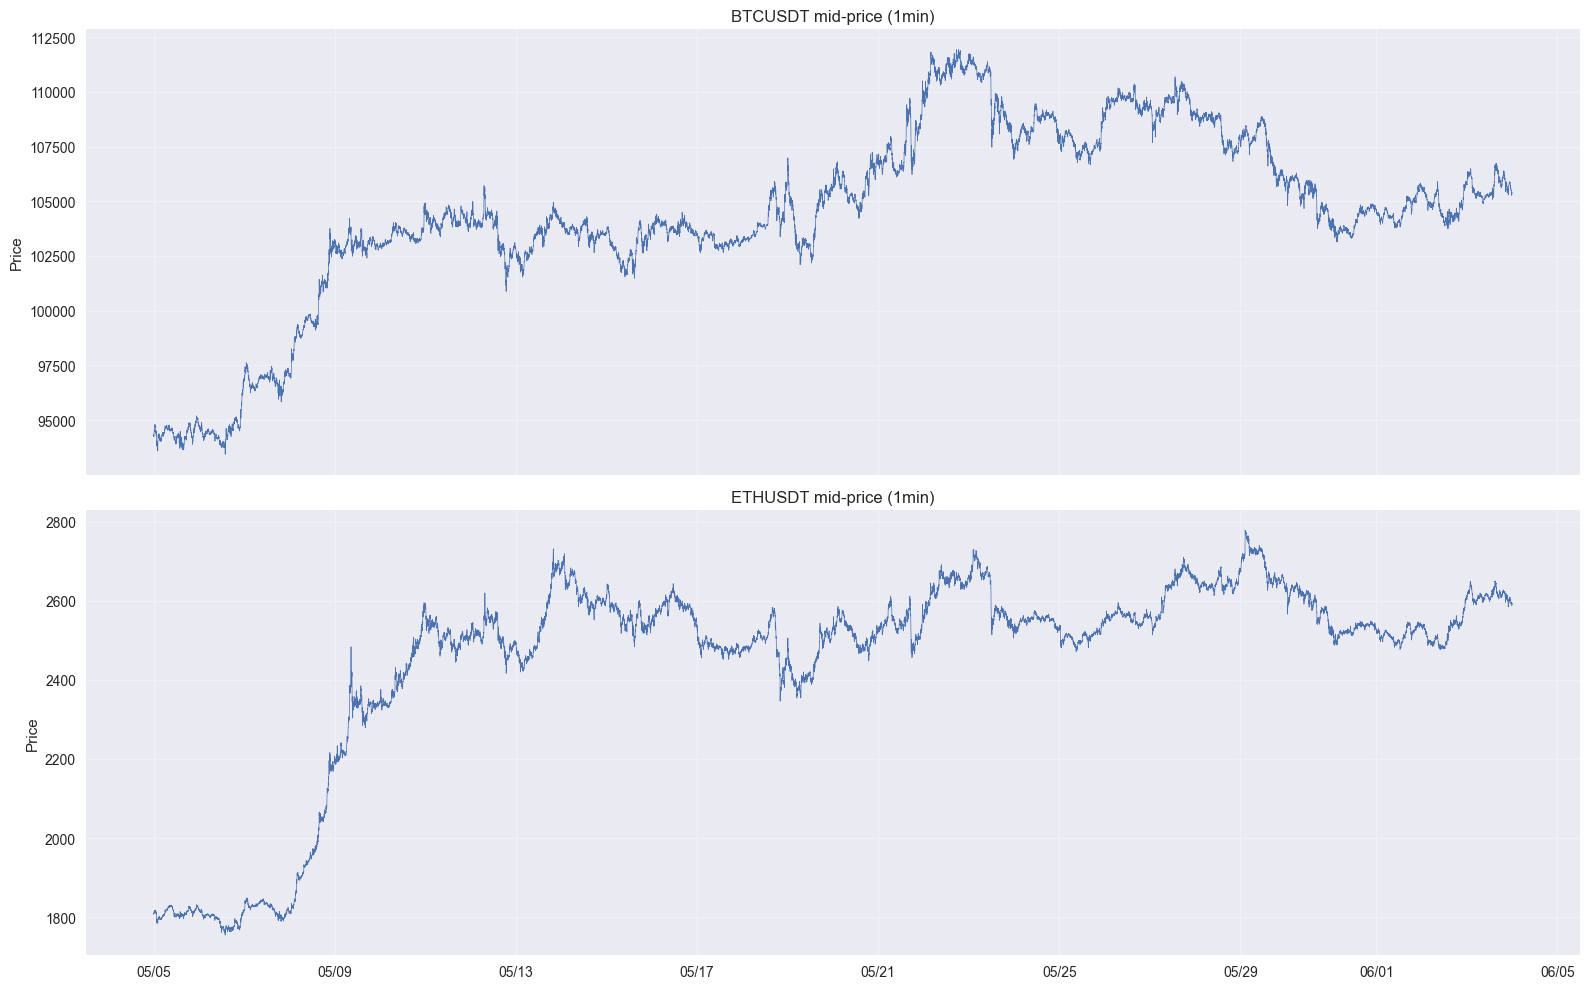

In [69]:
fig, axes = plt.subplots(len(SYMBOLS), 1, figsize=(16, 5 * len(SYMBOLS)), sharex=True)
if len(SYMBOLS) == 1:
    axes = [axes]

for ax, symbol in zip(axes, SYMBOLS):
    mid_plot = mid_series[symbol].resample("1min").mean().dropna()
    ax.plot(mid_plot.index, mid_plot.values, lw=0.5)
    ax.set_title(f"{symbol} mid-price (1min)")
    ax.set_ylabel("Price")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))

plt.tight_layout()
plt.show()

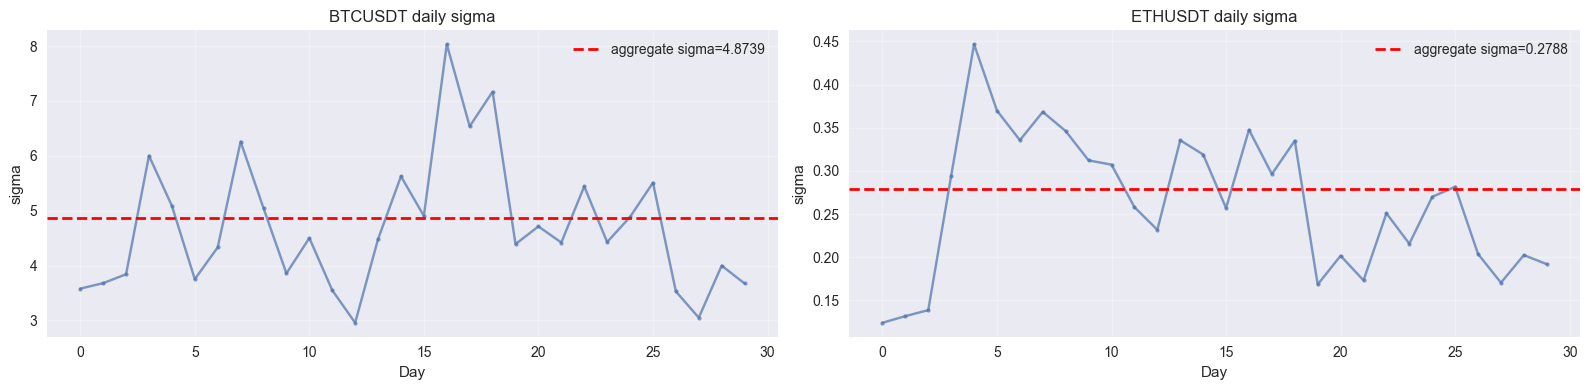

In [70]:
if not PIPELINE_DONE:
    fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(8 * len(SYMBOLS), 4))
    if len(SYMBOLS) == 1:
        axes = [axes]

    for ax, symbol in zip(axes, SYMBOLS):
        ds = fit_cache[symbol]["daily_sigma"]
        ax.plot(ds, "o-", ms=3, alpha=0.7)
        ax.axhline(calibrated[symbol]["sigma"], color="red", ls="--", lw=2,
                   label=f"aggregate sigma={calibrated[symbol]['sigma']:.4f}")
        ax.set_title(f"{symbol} daily sigma")
        ax.set_xlabel("Day")
        ax.set_ylabel("sigma")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

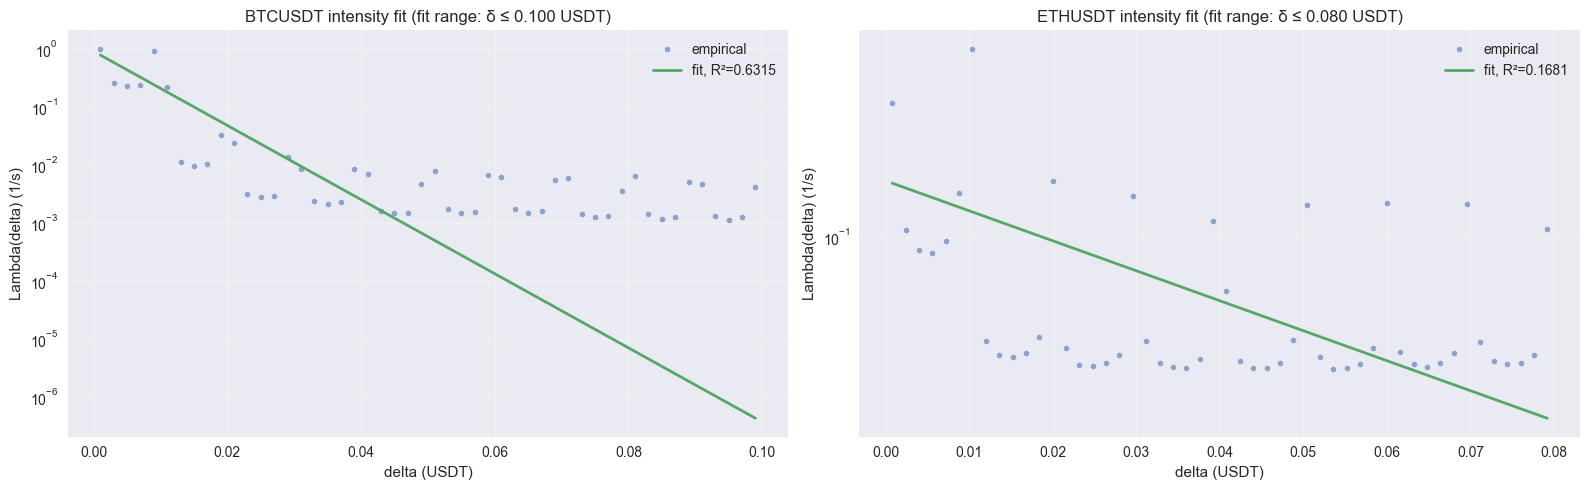

In [71]:
if not PIPELINE_DONE:
    fig, axes = plt.subplots(1, len(SYMBOLS), figsize=(8 * len(SYMBOLS), 5))
    if len(SYMBOLS) == 1:
        axes = [axes]

    for ax, symbol in zip(axes, SYMBOLS):
        c = fit_cache[symbol]["centers"]
        lo = fit_cache[symbol]["lam_obs"]
        lf = fit_cache[symbol]["lam_fit"]

        ax.semilogy(c, lo, "o", ms=4, alpha=0.6, label="empirical")
        ax.semilogy(c, lf, "-", lw=2, label=f"fit, R²={calibrated[symbol]['r_squared']:.4f}")
        ax.set_title(
            f"{symbol} intensity fit "
            f"(fit range: δ ≤ {fit_cache[symbol]['max_delta_used']:.3f} USDT)"
        )
        ax.set_xlabel("delta (USDT)")
        ax.set_ylabel("Lambda(delta) (1/s)")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

# CA NE MARCHE PAS 

Tu construis un modèle de market maker. Ce market maker pose des ordres à une certaine distance du milieu du marché — appelons cette distance δ (delta). Le modèle de Guéant dit : plus δ est grand (plus tu poses ton ordre loin du mid), moins tu as de chances d'être exécuté. Cette relation s'écrit Λ(δ) = A·e^{-kδ}.
Pour calibrer A et k depuis des vraies données, il faudrait mesurer : "pour chaque trade qui arrive, à quelle distance δ était-il du meilleur bid ou ask du moment ?"
Le problème : les données que tu as (aggTrades de Binance) ne contiennent que les trades exécutés — sans aucune information sur où étaient les ordres dans le carnet au moment du trade. C'est comme essayer de mesurer à quelle distance les voitures se garaient du trottoir en filmant uniquement les voitures qui ont déjà fini de se garer, sans voir le trottoir.
Pour approximer δ, tu calcules |prix du trade - VWAP de la seconde précédente|. Mais pour BTC, le prix bouge de ~0.90$ en une seconde rien qu'à cause de la volatilité normale. Donc ta mesure de δ capture surtout du bruit de mouvement de prix, pas de la vraie distance au spread. Résultat : ta distribution de δ est plate au lieu d'être décroissante, et le fit exponentiel ne marche pas.
Ce qu'il faudrait : des données L1 — c'est-à-dire le meilleur bid et meilleur ask à chaque instant (top of book), pour calculer le vrai mid = (bid + ask)/2 tick par tick.